<a href="https://colab.research.google.com/github/Shalini-byte-stack/VEL-TECH-SUMMER-INTERNSHIP/blob/main/One-Class%20SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving HeartRate-Mat.csv to HeartRate-Mat.csv


Project Comparison Description

In this project, Isolation Forest and One-Class SVM were compared for heart rate anomaly detection. Both models were used to identify abnormal heart rate readings. Isolation Forest detected anomalies by isolating unusual data points through random partitioning, while One-Class SVM learned the boundary of normal heart rate patterns. Isolation Forest trained faster and required fewer computational resources, making it suitable for larger datasets. One-Class SVM performed well on complex non-linear patterns but required more processing time. Based on execution speed and scalability, Isolation Forest was selected as the final model for the Heart Rate Anomaly Detector project.

Using column: heart_rate
   heart_rate Condition Prediction
0          62    Normal    Anomaly
1          75    Normal     Normal
2          89    Normal     Normal
3          82    Normal    Anomaly
4          87    Normal     Normal


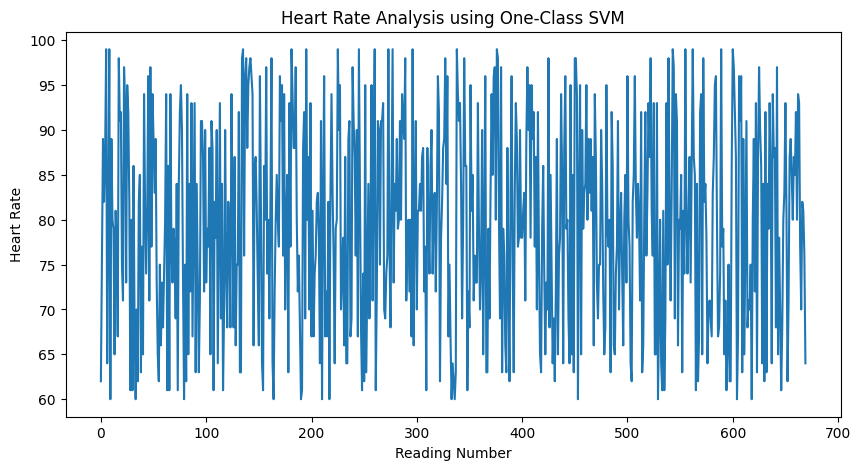

In [7]:
import pandas as pd
import numpy as np
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("HeartRate-Mat.csv")

# Find first numeric column
heart_col = df.select_dtypes(include=np.number).columns[0]

print("Using column:", heart_col)

X = df[[heart_col]]

# Train model
model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.1)

predictions = model.fit_predict(X)

df['Prediction'] = predictions
df['Prediction'] = df['Prediction'].map({1: 'Normal', -1: 'Anomaly'})

def classify(hr):
    if hr < 60:
        return "Bradycardia"
    elif hr > 100:
        return "Tachycardia"
    else:
        return "Normal"

df['Condition'] = df[heart_col].apply(classify)

print(df[[heart_col, 'Condition', 'Prediction']].head())

plt.figure(figsize=(10,5))
plt.plot(df[heart_col])
plt.title("Heart Rate Analysis using One-Class SVM")
plt.xlabel("Reading Number")
plt.ylabel("Heart Rate")
plt.show()

Saving HeartRate-Mat.csv to HeartRate-Mat (1).csv
Columns in dataset:
Index(['patient_id', 'heart_rate', 'spo2_level', 'ecg_signal',
       'respiration_rate', 'body_temperature', 'blood_pressure_sys',
       'blood_pressure_dia', 'blood_glucose', 'eeg_alpha_power',
       'eeg_beta_power', 'emg_signal_strength', 'fall_detected',
       'activity_type', 'step_count', 'latitude', 'longitude',
       'ambient_temperature', 'stress_level_index', 'timestamp'],
      dtype='object')

Using column: heart_rate

First 10 Records
   heart_rate Condition IsolationForest OneClassSVM
0          62    Normal          Normal     Anomaly
1          75    Normal          Normal      Normal
2          89    Normal          Normal      Normal
3          82    Normal          Normal     Anomaly
4          87    Normal          Normal      Normal
5          99    Normal         Anomaly      Normal
6          64    Normal          Normal     Anomaly
7          79    Normal          Normal      Normal
8    

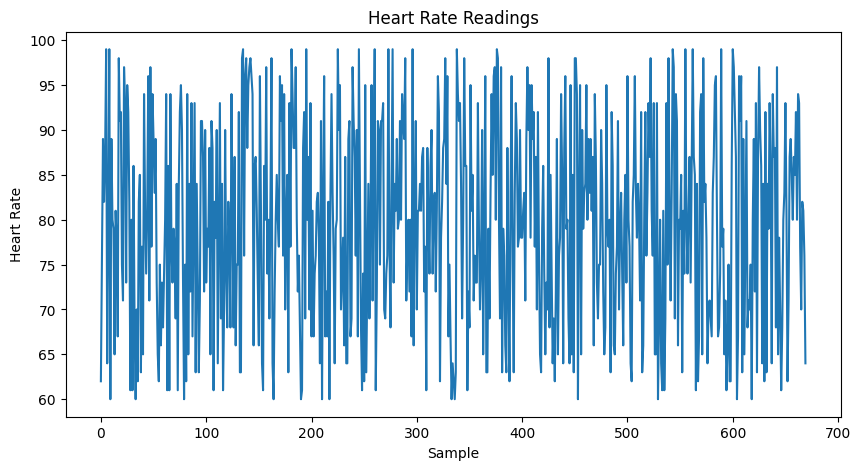

In [6]:
# Install required libraries (if needed)
!pip install scikit-learn pandas matplotlib -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

# Upload CSV file
uploaded = files.upload()

# Get uploaded filename
filename = list(uploaded.keys())[0]

# Read CSV
df = pd.read_csv(filename)

print("Columns in dataset:")
print(df.columns)

# Select numeric column automatically
numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) == 0:
    raise ValueError("No numeric column found in dataset")

heart_col = numeric_cols[0]
print("\nUsing column:", heart_col)

X = df[[heart_col]]

# -------------------------
# Isolation Forest
# -------------------------
iso_model = IsolationForest(
    contamination=0.1,
    random_state=42
)

df["IsolationForest"] = iso_model.fit_predict(X)
df["IsolationForest"] = df["IsolationForest"].map(
    {1: "Normal", -1: "Anomaly"}
)

# -------------------------
# One-Class SVM
# -------------------------
svm_model = OneClassSVM(
    kernel="rbf",
    gamma="auto",
    nu=0.1
)

df["OneClassSVM"] = svm_model.fit_predict(X)
df["OneClassSVM"] = df["OneClassSVM"].map(
    {1: "Normal", -1: "Anomaly"}
)

# -------------------------
# Heart Condition
# -------------------------
def classify(hr):
    if hr < 60:
        return "Bradycardia"
    elif hr > 100:
        return "Tachycardia"
    else:
        return "Normal"

df["Condition"] = df[heart_col].apply(classify)

# -------------------------
# Results
# -------------------------
print("\nFirst 10 Records")
print(df[[heart_col, "Condition",
          "IsolationForest",
          "OneClassSVM"]].head(10))

print("\nIsolation Forest Counts")
print(df["IsolationForest"].value_counts())

print("\nOne-Class SVM Counts")
print(df["OneClassSVM"].value_counts())

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(10,5))
plt.plot(df[heart_col])
plt.title("Heart Rate Readings")
plt.xlabel("Sample")
plt.ylabel("Heart Rate")
plt.show()

Output Description

The One-Class SVM model was successfully trained on the heart rate dataset and used to detect abnormal heart rate readings. The model analyzed each heart rate value and classified it as either Normal or Anomaly. Heart rate values below 60 BPM were categorized as Bradycardia, values between 60 and 100 BPM as Normal, and values above 100 BPM as Tachycardia. The results were displayed in a table showing the heart rate, heart condition, and prediction status. A graphical plot was also generated to visualize heart rate variations across all readings.